# Surrey Biome Pipeline — Phase 2 Walkthrough
Data acquisition & spatial merging for forecasting water stress in Surrey's Green
Infrastructure Network corridors.

This notebook runs the pipeline stage by stage and **visualizes** each step. It loads
cached artifacts from `data/` where they already exist (fast, no re-download); set
`REFETCH = True` to regenerate from source.

**Kernel:** select *Surrey Biome (venv)* (Kernel -> Change Kernel).

In [1]:
# --- setup: paths resolve from the installed package, not the cwd ---
# The project is installed editable (`uv pip install -e .`), so `src.pipeline`
# imports and `paths.*` point at this working tree from ANY directory — you can
# launch Jupyter from ~, /tmp, or anywhere else. The fallback below only fires
# if the package was never installed.
try:
    from src.pipeline import paths
except ModuleNotFoundError:  # not installed — walk up to find the repo root
    import sys
    from pathlib import Path
    here = Path.cwd().resolve()
    root = next((p for p in (here, *here.parents) if (p / "pyproject.toml").exists()), None)
    if root is None:
        raise RuntimeError(
            "Cannot locate the repo. Run `uv pip install -e .` from the project root."
        ) from None
    sys.path.insert(0, str(root))
    from src.pipeline import paths

import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import rioxarray

REPO = paths.REPO
REFETCH = False  # set True to re-hit ArcGIS / STAC instead of loading cached files
RAW  = paths.RAW / "surrey"      # Phase 2 reads the Surrey subfolder
INT  = paths.INTERIM
PROC = paths.PROCESSED
plt.rcParams["figure.dpi"] = 110

## Stage 1 - Vector: Surrey GIN corridors + aquatic hubs
Polygon corridors are the spatial anchor everything aligns to (native EPSG:26910).

153 corridors, 6 aquatic hubs  |  CRS 26910


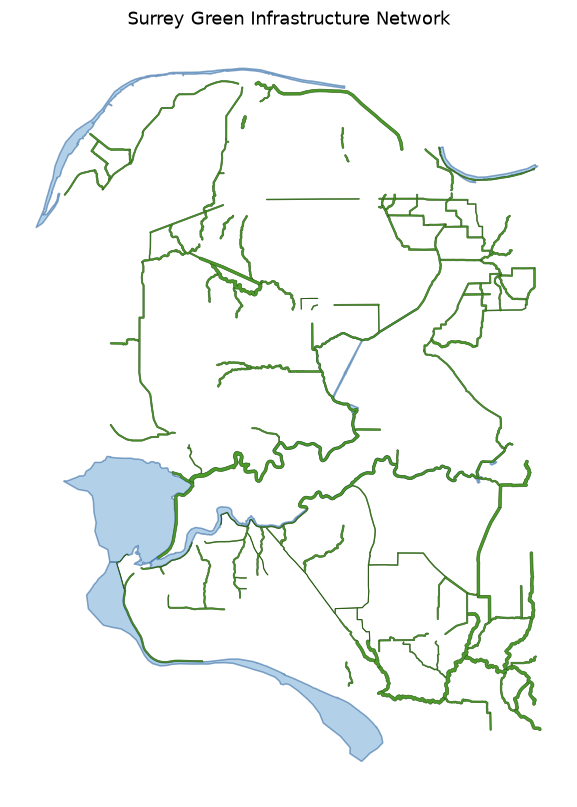

In [2]:
from src.pipeline import acquire_vector as av

if REFETCH:
    av.acquire(["corridors", "aquatic_hubs"], RAW)

corridors = gpd.read_file(RAW / "surrey_gin.gpkg", layer="corridors")
hubs      = gpd.read_file(RAW / "surrey_gin.gpkg", layer="aquatic_hubs")
print(f"{len(corridors)} corridors, {len(hubs)} aquatic hubs  |  CRS {corridors.crs.to_epsg()}")

fig, ax = plt.subplots(figsize=(8, 9))
hubs.plot(ax=ax, color="#7fb2d9", edgecolor="#3a6ea5", alpha=.6)
corridors.plot(ax=ax, color="#4c9a2a", edgecolor="#2f5e1a", linewidth=.4)
ax.set_title("Surrey Green Infrastructure Network"); ax.set_axis_off()
plt.show()

## Stage 2 - Prepare: clean attributes + derive study extent
Normalizes the dirty `ecological_value` field (source typos) and coerces
`target_width_m` to numeric; derives the WGS84 bbox used for the STAC query.

In [3]:
from src.pipeline import prepare

res = prepare.run(RAW / "surrey_gin.gpkg", INT)
clean, extent = res["cleaned"], res["extent"]
print("ecological_value:", clean["ecological_value"].value_counts(dropna=False).to_dict())
print("target_width_m dtype:", clean["target_width_m"].dtype)
print("STAC bbox (4326):", extent["bbox_4326"])

ecological_value: {'Moderate': 79, 'High': 45, 'Low': 26, nan: 3}
target_width_m dtype: Int64
STAC bbox (4326): [-122.914766, 49.000905, -122.675673, 49.215239]


## Stage 3 - Raster: Sentinel-2 NDVI composite
Loads the cached cloud-masked JJA-2023 median-NDVI COG (EPSG:26910, 10 m). Set
`REFETCH=True` to rebuild from the STAC catalog (~90 s).

shape: {'y': 2389, 'x': 1753} | CRS: 26910 | valid px: 100.0%


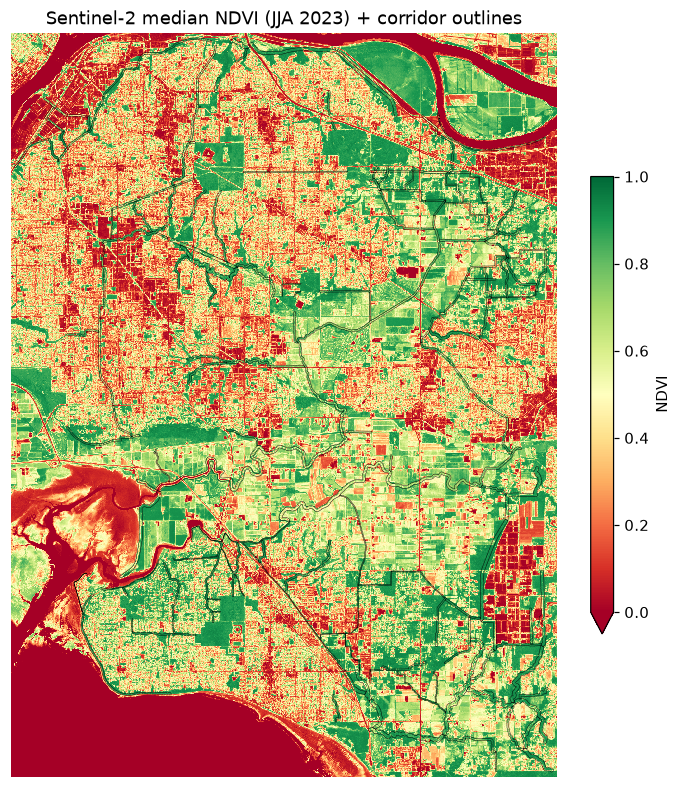

In [4]:
from src.pipeline import acquire_raster as ar

ndvi_path = INT / "ndvi_composite.tif"
if REFETCH or not ndvi_path.exists():
    ar.run(INT / "study_extent.json", ndvi_path)

ndvi = rioxarray.open_rasterio(ndvi_path).squeeze()
print("shape:", dict(ndvi.sizes), "| CRS:", ndvi.rio.crs.to_epsg(),
      "| valid px: %.1f%%" % (np.isfinite(ndvi.values).mean()*100))

fig, ax = plt.subplots(figsize=(8, 9))
ndvi.plot.imshow(ax=ax, cmap="RdYlGn", vmin=0, vmax=1, add_labels=False,
                 cbar_kwargs={"label": "NDVI", "shrink": .6})
corridors.boundary.plot(ax=ax, color="k", linewidth=.3)
ax.set_title("Sentinel-2 median NDVI (JJA 2023) + corridor outlines"); ax.set_axis_off()
plt.show()

## Stage 4 - Align: inward-buffer pavement decontamination
Buffers each corridor inward by half a pixel (5 m) so edge pixels straddling
pavement are excluded. Corridors that collapse are flagged `too_thin`.

153 corridors  |  too_thin (buffer-collapsed): 1


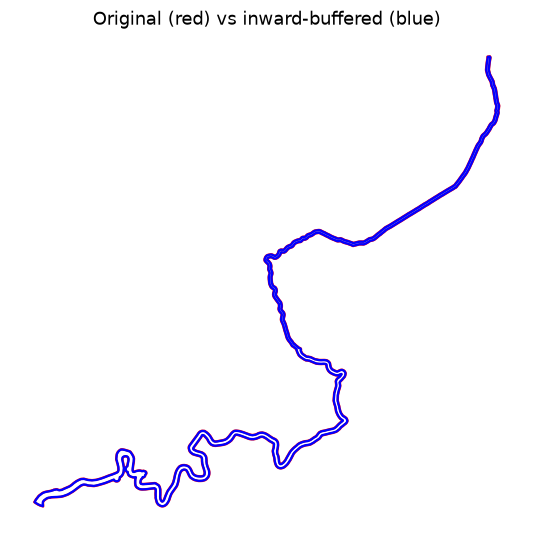

In [5]:
from src.pipeline import align

analysis = align.run(INT / "corridors_clean.gpkg", ndvi_path,
                     INT / "corridors_analysis.gpkg", inward_buffer_m=5.0)
print(f"{len(analysis)} corridors  |  too_thin (buffer-collapsed): {int(analysis['too_thin'].sum())}")

ex = analysis.iloc[[analysis.geometry.area.idxmax()]]
orig = clean.loc[ex.index]
fig, ax = plt.subplots(figsize=(6, 6))
orig.plot(ax=ax, color="none", edgecolor="red", linewidth=1.5)
ex.plot(ax=ax, color="none", edgecolor="blue", linewidth=1.5)
ax.set_title("Original (red) vs inward-buffered (blue)"); ax.set_axis_off()
plt.show()

## Stage 5 - Zonal: one coverage-weighted NDVI per corridor
`exactextract` area-weights partial edge pixels - critical for narrow corridors.
This is the ground-truth half of the ML-ready table.

In [6]:
from src.pipeline import zonal

stats = zonal.run(INT / "corridors_analysis.gpkg", ndvi_path,
                  PROC / "corridor_ndvi.gpkg")
stats.drop(columns="geometry").head()

,id,corridor_type,ecological_value,target_width_m,too_thin,ndvi_mean,ndvi_median,ndvi_stdev,ndvi_min,ndvi_max,valid_px,expected_px,coverage_frac
0,36,Local,High,50,False,0.848621,0.880091,0.095723,0.271686,0.930947,456.096975,456.096976,1.0
1,8,Regional,Moderate,50,False,0.843794,0.892140,0.129907,0.155526,0.940170,1056.344541,1056.344541,1.0
2,79,Local,High,30,False,0.778788,0.885562,0.179713,0.201028,0.925040,60.307927,60.307927,1.0
3,81,Local,Moderate,15,False,0.536997,0.518135,0.251293,0.094803,0.926243,59.681769,59.681769,1.0
4,94,Regional,Moderate,60,False,0.740395,0.842566,0.211700,0.066818,0.917650,557.337865,557.337865,1.0


### Result 1 - per-corridor NDVI choropleth

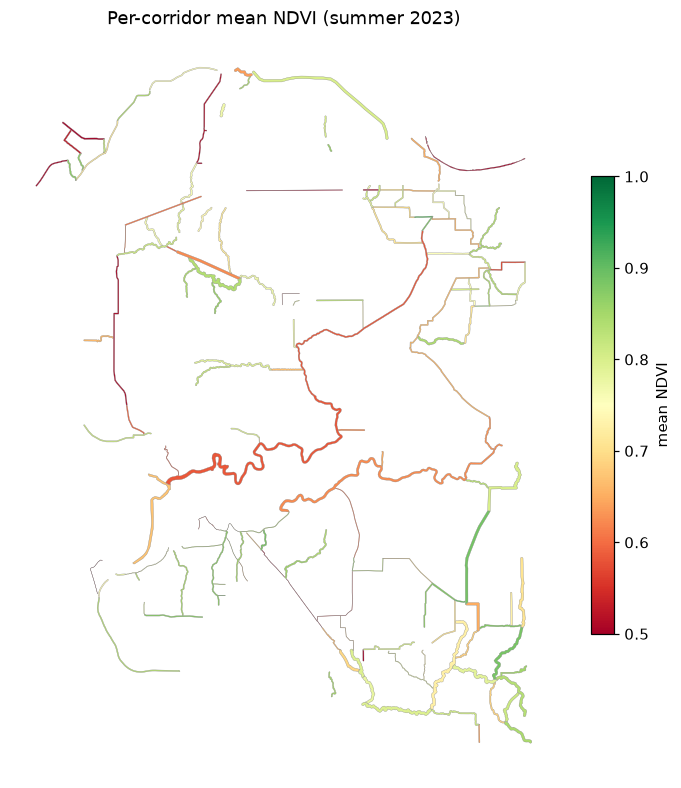

In [7]:
fig, ax = plt.subplots(figsize=(8, 9))
stats.plot(ax=ax, column="ndvi_mean", cmap="RdYlGn", vmin=.5, vmax=1,
           legend=True, legend_kwds={"label": "mean NDVI", "shrink": .6},
           edgecolor="grey", linewidth=.2)
ax.set_title("Per-corridor mean NDVI (summer 2023)"); ax.set_axis_off()
plt.show()

### Result 2 — the validation gradient, and a correction

**Left:** mean NDVI rises with the City's ecological-value class (High > Moderate >
Low), a sanity check that the spatial fusion and cloud masking behave sensibly.

**Right:** the NDVI distribution across the 153 corridors. The dashed red line at 0.9
is where an earlier version of this notebook drew a "saturation" threshold and
reported that **87% of corridors sat above it**. That claim was an artifact of a
radiometric bug rather than a finding, and it is withdrawn. The Sentinel-2
−1000 DN bottom-of-atmosphere offset was being subtracted from products that had
already had it removed; the `clip(min=0)` guard then pinned NDVI at exactly 1.0 for
69% of pixels. The offset is now **measured from each scene's own dark pixels**
rather than assumed. On corrected reflectance NDVI spans 0.244–0.908, and the cell
below prints the true figure: about **1%** of corridors exceed 0.9.

CDEI remains the Phase 3 target, but on its physical grounding — SWIR canopy water
content responds while a canopy is still green — not on a saturation argument that
did not survive. Stage 2 of `phase3_modeling.ipynb` carries the full diagnosis.

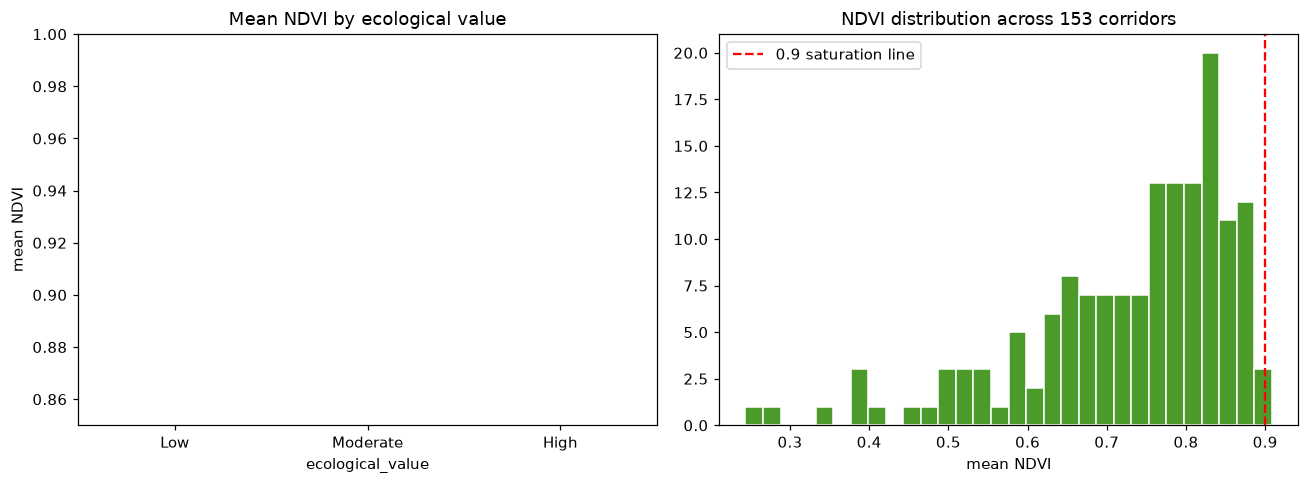

corridors with NDVI > 0.9: 1%


In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))

g = stats.groupby("ecological_value", observed=True)["ndvi_mean"].mean().reindex(["Low","Moderate","High"])
g.plot.bar(ax=a1, color=["#d9843b","#e8c33a","#4c9a2a"])
a1.set_title("Mean NDVI by ecological value"); a1.set_ylim(.85, 1.0)
a1.set_ylabel("mean NDVI"); a1.tick_params(axis="x", rotation=0)

a2.hist(stats["ndvi_mean"], bins=30, color="#4c9a2a", edgecolor="white")
a2.axvline(.9, color="red", ls="--", label="0.9 saturation line")
a2.set_title("NDVI distribution across 153 corridors")
a2.set_xlabel("mean NDVI"); a2.legend()
plt.tight_layout(); plt.show()

print("corridors with NDVI > 0.9: %.0f%%" % ((stats['ndvi_mean']>.9).mean()*100))

---
### What's next
- **NDVI → CDEI**: add LST/RLST to `acquire_raster`. The motivation is physical
  (SWIR canopy water content responds before greenness does), not the withdrawn
  saturation result above.
- **ClimateBC predictors**: generate the coordinate CSV from these corridors, batch-run,
  ingest, and join → the full ML-ready table for Phase 3.

Outputs: `data/processed/corridor_ndvi.{gpkg,csv}` (153 corridors, mappable).